## AY's KAN vs MLP

In [1]:
pip install kagglehub pykan scikit_learn matplotlib numpy setuptools sympy torch tqdm pandas seaborn pyyaml

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ================================
# Step 0 - LIBRARY INSTALLATION
# ================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

import kagglehub
import os

from sklearn.preprocessing import StandardScaler

from kan import *

torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

print("All libraries loaded successfully!")

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


cuda
All libraries loaded successfully!


In [3]:
# Download latest version
path = kagglehub.dataset_download("harlfoxem/housesalesprediction")

# print("Path to dataset files:", path)

# Combine path with the expected CSV filename
dataset_path = os.path.join(path, "kc_house_data.csv")

In [4]:
# ================================
# STEP 1: DATASET CLASS DEFINITION
# ================================

class HouseDataset(Dataset):
    def __init__(self, csv_file):
        print(f"Loading dataset from: {csv_file}")
        self.data = pd.read_csv(csv_file)
        print(f"Dataset loaded with {len(self.data)} houses")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        house = self.data.iloc[idx]

        features = torch.tensor([house['lat'], house['long'], house['sqft_living'], house['zipcode'], house['price']], dtype=torch.float32)
        target = torch.tensor(house['view'], dtype=torch.float32)

        sample = {'features': features, 'target': target}
        return sample

In [5]:
# ================================
# STEP 2: CREATE DATASET AND DATALOADERS
# ================================
dataset = HouseDataset(dataset_path)
train_dataset, test_dataset, val_dataset = random_split(dataset, [0.7, 0.2, 0.1])

scaler = StandardScaler()
# Fit the scaler on the training data
train_features = torch.stack([sample['features'] for sample in train_dataset])
scaler.fit(train_features)

# Transform the features using the fitted scaler
for sample in train_dataset:
    sample['features'] = torch.tensor(scaler.transform([sample['features'].numpy()])[0], dtype=torch.float32)

for sample in val_dataset:
    sample['features'] = torch.tensor(scaler.transform([sample['features'].numpy()])[0], dtype=torch.float32)

for sample in test_dataset:
    sample['features'] = torch.tensor(scaler.transform([sample['features'].numpy()])[0], dtype=torch.float32)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Examine a batch of training data
print("Examining a batch of training data:")
for batch in train_loader:
    print(f"Batch features shape: {batch['features'].shape}")
    print(f"Batch target shape: {batch['target'].shape}")
    print(f"Sample features: {batch['features'][0]}")
    print(f"Sample target: {batch['target'][0]}")
    break  # Just examine the first batch

Loading dataset from: /home/alaguda/.cache/kagglehub/datasets/harlfoxem/housesalesprediction/versions/1/kc_house_data.csv
Dataset loaded with 21613 houses
Train dataset size: 15130
Validation dataset size: 2161
Test dataset size: 4322
Examining a batch of training data:
Batch features shape: torch.Size([32, 5])
Batch target shape: torch.Size([32])
Sample features: tensor([ 4.7556e+01, -1.2213e+02,  2.4500e+03,  9.8006e+04,  7.6000e+05])
Sample target: 2.0


In [6]:
# ================================
# STEP 3: MODEL DEFINITIONS
# ================================

# 4 nodes input layer, 32 node hidden 1, 16 hidden 2, 5 nodes output layer
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, output_size)
        # self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        # out = self.softmax(out)
        return out

# Create an instance of the MLP model
# The 'view' column in the dataset has 5 unique classes (0, 1, 2, 3, 4), so we need an output size of 5 to represent the probabilities for each class.
model = MLP(input_size=5, hidden_size1=32, hidden_size2=16, output_size=5)

print(f"Model architecture:\n{model}")

# #Show initial weights and biases
# for name, param in model.named_parameters():
#     if param.requires_grad:
#         print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]}")

Model architecture:
MLP(
  (fc1): Linear(in_features=5, out_features=32, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=16, out_features=5, bias=True)
)


In [7]:
# KAN model definition

# create a KAN (Kolmogorov-Arnold Network) model with the same input and output sizes as the MLP
model_KAN = KAN(width=[5,10,10,5], grid=5, k=3, seed=42)

# torch.stack([sample['features'] for sample in train_dataset]).shape

checkpoint directory created: ./model
saving model version 0.0


KAN Model architecture:


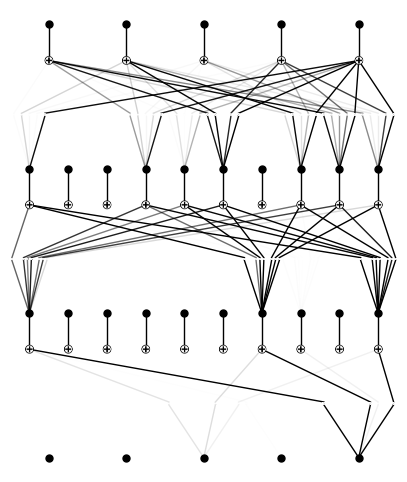

In [8]:
print("KAN Model architecture:")

# plot KAN at initialization
model_KAN(torch.stack([sample['features'] for sample in train_dataset]))
model_KAN.plot()

In [9]:
# ================================
# STEP 4: LOSS FUNCTION AND OPTIMIZER
# ================================
class_labels = np.array([sample['target'] for sample in train_dataset])
w = torch.tensor(compute_class_weight(class_weight='balanced', classes=np.arange(5), y=class_labels), dtype=torch.float)

criterion = nn.CrossEntropyLoss(weight=w)
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# KAN optimizer
optimizer_KAN = torch.optim.Adam(model_KAN.parameters(), lr=learning_rate)

In [10]:
# ================================
# STEP 5: TRAINING LOOP
# ================================

num_epochs = 20

print("MLP Starting training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, batch in enumerate(train_loader):
        features = batch['features']
        targets = batch['target'].long()  # Convert to long for CrossEntropyLoss

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, targets)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

    # Validation step
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            features = batch['features']
            targets = batch['target'].long()

            outputs = model(features)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    print(f"Validation Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%")

print("MLP Training completed.")

print("========================================")

MLP Starting training...
Epoch [1/20], Loss: 2172.3974
Validation Loss: 687.9742, Accuracy: 88.99%
Epoch [2/20], Loss: 833.9202
Validation Loss: 664.7422, Accuracy: 1.25%
Epoch [3/20], Loss: 711.5477
Validation Loss: 137.8618, Accuracy: 15.96%
Epoch [4/20], Loss: 563.5470
Validation Loss: 855.0534, Accuracy: 3.61%
Epoch [5/20], Loss: 553.0426
Validation Loss: 529.9379, Accuracy: 73.62%
Epoch [6/20], Loss: 445.6509
Validation Loss: 192.7423, Accuracy: 80.61%
Epoch [7/20], Loss: 414.7437
Validation Loss: 307.1446, Accuracy: 16.29%
Epoch [8/20], Loss: 444.3815
Validation Loss: 291.4632, Accuracy: 3.33%
Epoch [9/20], Loss: 335.1802
Validation Loss: 167.4049, Accuracy: 84.27%
Epoch [10/20], Loss: 402.9027
Validation Loss: 142.4237, Accuracy: 88.39%
Epoch [11/20], Loss: 346.5534
Validation Loss: 118.2125, Accuracy: 8.42%
Epoch [12/20], Loss: 272.6901
Validation Loss: 215.6759, Accuracy: 34.01%
Epoch [13/20], Loss: 240.9188
Validation Loss: 126.2542, Accuracy: 30.36%
Epoch [14/20], Loss: 244.

In [11]:
print("KAN Starting training...")
for epoch in range(num_epochs):
    model_KAN.train()
    running_loss = 0.0
    for i, batch in enumerate(train_loader):
        features = batch['features']
        targets = batch['target'].long()  # Convert to long for CrossEntropyLoss

        # Zero the parameter gradients
        optimizer_KAN.zero_grad()

        # Forward pass
        outputs = model_KAN(features)
        loss = criterion(outputs, targets)

        # Backward pass and optimization
        loss.backward()
        optimizer_KAN.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

    # Validation step
    model_KAN.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            features = batch['features']
            targets = batch['target'].long()

            outputs = model_KAN(features)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    print(f"Validation Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%")

print("KAN Training completed.")

KAN Starting training...
Epoch [1/20], Loss: 1171.6348
Validation Loss: 274.2642, Accuracy: 1.30%
Epoch [2/20], Loss: 246.9440
Validation Loss: 76.9165, Accuracy: 1.94%
Epoch [3/20], Loss: 186.9702
Validation Loss: 116.3461, Accuracy: 79.36%
Epoch [4/20], Loss: 210.0835
Validation Loss: 304.9784, Accuracy: 91.58%
Epoch [5/20], Loss: 217.0560
Validation Loss: 140.1830, Accuracy: 56.92%
Epoch [6/20], Loss: 186.2859
Validation Loss: 167.7826, Accuracy: 2.87%
Epoch [7/20], Loss: 141.4445
Validation Loss: 164.8004, Accuracy: 23.18%
Epoch [8/20], Loss: 138.9018
Validation Loss: 108.7404, Accuracy: 5.65%
Epoch [9/20], Loss: 188.3563
Validation Loss: 146.4601, Accuracy: 2.55%
Epoch [10/20], Loss: 113.8828
Validation Loss: 76.8006, Accuracy: 11.15%
Epoch [11/20], Loss: 83.0807
Validation Loss: 26.8212, Accuracy: 60.53%
Epoch [12/20], Loss: 82.9581
Validation Loss: 31.1808, Accuracy: 31.37%
Epoch [13/20], Loss: 51.6837
Validation Loss: 31.1580, Accuracy: 31.37%
Epoch [14/20], Loss: 46.2324
Valid

In [12]:
# ================================
# STEP 6: TESTING
# ================================

from sklearn.metrics import confusion_matrix

print("MLP Testing Results:")

model.eval()
test_loss = 0.0
correct = 0
total = 0

# Making a Confusion Matrix for the test set
all_targets = []
all_predictions = []

with torch.no_grad():
    for batch in test_loader:
        features = batch['features']
        targets = batch['target'].long()

        outputs = model(features)
        loss = criterion(outputs, targets)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        all_targets.extend(targets.numpy())
        all_predictions.extend(predicted.numpy())

avg_test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total
print(f"Test Loss: {avg_test_loss:.4f}, Accuracy: {test_accuracy:.2f}%")

cm = confusion_matrix(all_targets, all_predictions)

# to know which class is which, we can print the unique classes in the dataset
unique_classes = np.unique(all_targets)

print("Row is the actual class, column is the predicted class.")
print("Confusion Matrix:")
print(cm)
print("Unique Classes:")
print(unique_classes)

print("========================================")

MLP Testing Results:
Test Loss: 1.5841, Accuracy: 89.73%
Row is the actual class, column is the predicted class.
Confusion Matrix:
[[3878    0    0    0    0]
 [  66    0    0    0    0]
 [ 203    0    0    0    0]
 [ 113    0    0    0    0]
 [  62    0    0    0    0]]
Unique Classes:
[0 1 2 3 4]


In [13]:
print("KAN Testing Results:")
# KAN Testing

model_KAN.eval()
kan_test_loss = 0.0
correct = 0
total = 0

all_targets = []
all_predictions = []

with torch.no_grad():
    for batch in test_loader:
        features = batch['features']
        targets = batch['target'].long()

        outputs = model_KAN(features)
        loss = criterion(outputs, targets)
        kan_test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        all_targets.extend(targets.numpy())
        all_predictions.extend(predicted.numpy())

avg_kan_test_loss = kan_test_loss / len(test_loader)
kan_test_accuracy = 100 * correct / total
print(f"KAN Test Loss: {avg_kan_test_loss:.4f}, Accuracy: {kan_test_accuracy:.2f}%")

kan_cm = confusion_matrix(all_targets, all_predictions)
print("KAN Confusion Matrix:")
print(kan_cm)
print("Unique Classes for KAN:")
print(np.unique(all_targets))

KAN Testing Results:
KAN Test Loss: 1.5869, Accuracy: 89.73%
KAN Confusion Matrix:
[[3877    0    0    0    1]
 [  66    0    0    0    0]
 [ 203    0    0    0    0]
 [ 113    0    0    0    0]
 [  61    0    0    0    1]]
Unique Classes for KAN:
[0 1 2 3 4]


In [14]:
# ================================
# STEP 7: MAKE PREDICTIONS ON TEST SET
# ================================

print("MLP Predictions:")

# Make predictions on the test set and display some results
model.eval()
with torch.no_grad():
    for batch in test_loader:
        features = batch['features']
        targets = batch['target'].long()

        outputs = model(features)
        _, predicted = torch.max(outputs.data, 1)

        # Display some results
        for j in range(len(features)):
            print(f"Sample {j}: Predicted={predicted[j]}, Actual={targets[j]}")
        break  # Just show predictions for the first batch

print("========================================")

MLP Predictions:
Sample 0: Predicted=0, Actual=0
Sample 1: Predicted=0, Actual=3
Sample 2: Predicted=0, Actual=0
Sample 3: Predicted=0, Actual=0
Sample 4: Predicted=0, Actual=0
Sample 5: Predicted=0, Actual=0
Sample 6: Predicted=0, Actual=0
Sample 7: Predicted=0, Actual=0
Sample 8: Predicted=0, Actual=0
Sample 9: Predicted=0, Actual=0
Sample 10: Predicted=0, Actual=0
Sample 11: Predicted=0, Actual=3
Sample 12: Predicted=0, Actual=0
Sample 13: Predicted=0, Actual=0
Sample 14: Predicted=0, Actual=0
Sample 15: Predicted=0, Actual=3
Sample 16: Predicted=0, Actual=0
Sample 17: Predicted=0, Actual=0
Sample 18: Predicted=0, Actual=0
Sample 19: Predicted=0, Actual=0
Sample 20: Predicted=0, Actual=0
Sample 21: Predicted=0, Actual=0
Sample 22: Predicted=0, Actual=0
Sample 23: Predicted=0, Actual=0
Sample 24: Predicted=0, Actual=0
Sample 25: Predicted=0, Actual=0
Sample 26: Predicted=0, Actual=0
Sample 27: Predicted=0, Actual=0
Sample 28: Predicted=0, Actual=0
Sample 29: Predicted=0, Actual=0
Sam

In [15]:
print("KAN Predictions:")
# Make predictions on the test set using the KAN model and display some results
model_KAN.eval()
with torch.no_grad():
    for batch in test_loader:
        features = batch['features']
        targets = batch['target'].long()

        outputs = model_KAN(features)
        _, predicted = torch.max(outputs.data, 1)

        # Display some results
        for j in range(len(features)):
            print(f"Sample {j}: Predicted={predicted[j]}, Actual={targets[j]}")
        break  # Just show predictions for the first batch

print("========================================")

KAN Predictions:
Sample 0: Predicted=0, Actual=0
Sample 1: Predicted=0, Actual=3
Sample 2: Predicted=0, Actual=0
Sample 3: Predicted=0, Actual=0
Sample 4: Predicted=0, Actual=0
Sample 5: Predicted=0, Actual=0
Sample 6: Predicted=0, Actual=0
Sample 7: Predicted=0, Actual=0
Sample 8: Predicted=0, Actual=0
Sample 9: Predicted=0, Actual=0
Sample 10: Predicted=0, Actual=0
Sample 11: Predicted=0, Actual=3
Sample 12: Predicted=0, Actual=0
Sample 13: Predicted=0, Actual=0
Sample 14: Predicted=0, Actual=0
Sample 15: Predicted=0, Actual=3
Sample 16: Predicted=0, Actual=0
Sample 17: Predicted=0, Actual=0
Sample 18: Predicted=0, Actual=0
Sample 19: Predicted=0, Actual=0
Sample 20: Predicted=0, Actual=0
Sample 21: Predicted=0, Actual=0
Sample 22: Predicted=0, Actual=0
Sample 23: Predicted=0, Actual=0
Sample 24: Predicted=0, Actual=0
Sample 25: Predicted=0, Actual=0
Sample 26: Predicted=0, Actual=0
Sample 27: Predicted=0, Actual=0
Sample 28: Predicted=0, Actual=0
Sample 29: Predicted=0, Actual=0
Sam